데이터 기준일 : 2026-08-14
KOSPI        : 6,977.94
MA200        : 5,873.23
시장 상태    : 상승장
분석 대상 종목 : 832

[매수 후보 TOP 20]


,Code,Name,Close,BuyScore,20일(%),6-1M(%),MA20이격(%),거래대금(억),유형,위험도,해석
0,475150,SK이터닉스,58300,79.81,12.12,135.84,5.25,4774.99,강한추세,높음,추세는 매우 강하지만 이미 많이 오른 종목
1,006340,대원전선,14710,73.93,20.28,256.38,8.69,2124.93,강한추세,높음,추세는 매우 강하지만 이미 많이 오른 종목
2,021240,코웨이,98200,72.02,1.55,15.86,4.93,167.48,균형형,낮음,추세와 과열 정도의 균형이 좋은 종목
3,010950,S-Oil,147600,66.05,1.86,40.96,8.35,558.10,일반,보통,무난한 상승 추세 종목
4,001800,오리온홀딩스,26800,57.82,2.88,13.97,2.79,20.98,저과열,낮음,과열은 적지만 상승 힘을 더 확인할 종목
5,417310,코람코더원리츠,10930,51.46,9.96,13.86,2.15,18.95,저과열,낮음,과열은 적지만 상승 힘을 더 확인할 종목
6,005430,한국공항,86200,50.74,0.58,27.30,0.80,14.63,균형형,낮음,추세와 과열 정도의 균형이 좋은 종목
7,003690,코리안리,15290,41.35,11.93,9.98,9.18,41.98,일반,보통,무난한 상승 추세 종목
8,089860,롯데렌탈,45000,27.95,22.45,4.78,12.16,64.36,급등주의,높음,최근 급등하여 추격매수 주의



[균형형 - TOP 10]


,Code,Name,Close,MA20,MA60,매수가,손절가,1R(30%매도),2R(30%매도),현재단계,매도신호
2,021240,코웨이,98200,93585.0,92142.0,98200.0,92142.0,104258.0,110317.0,1R 전,보유
6,005430,한국공항,86200,85515.0,82603.0,86200.0,82603.0,89797.0,93393.0,1R 전,보유


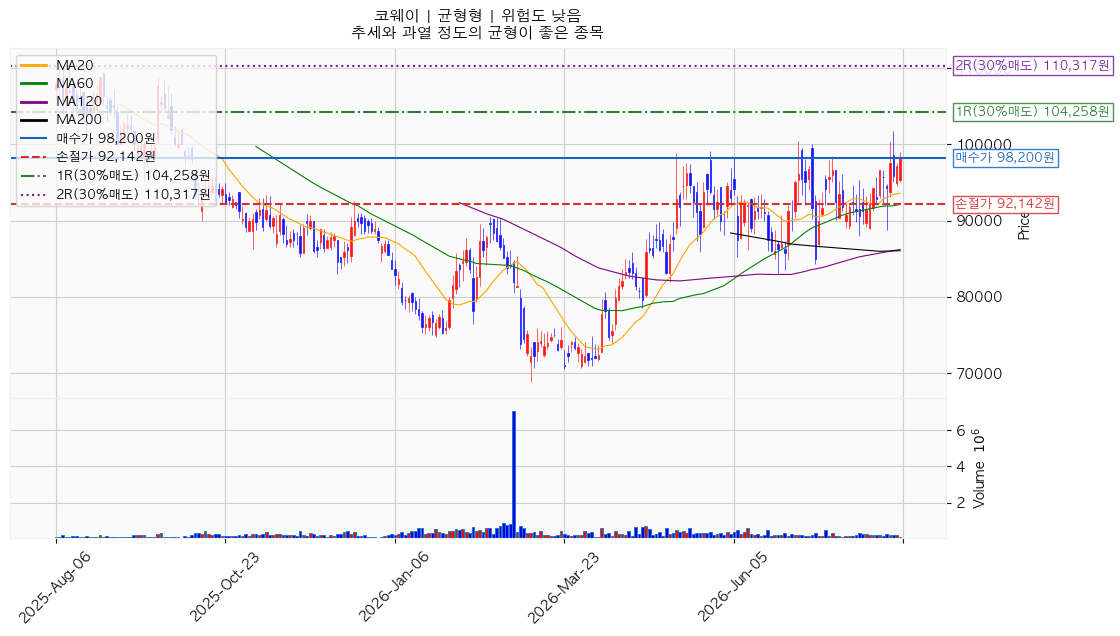

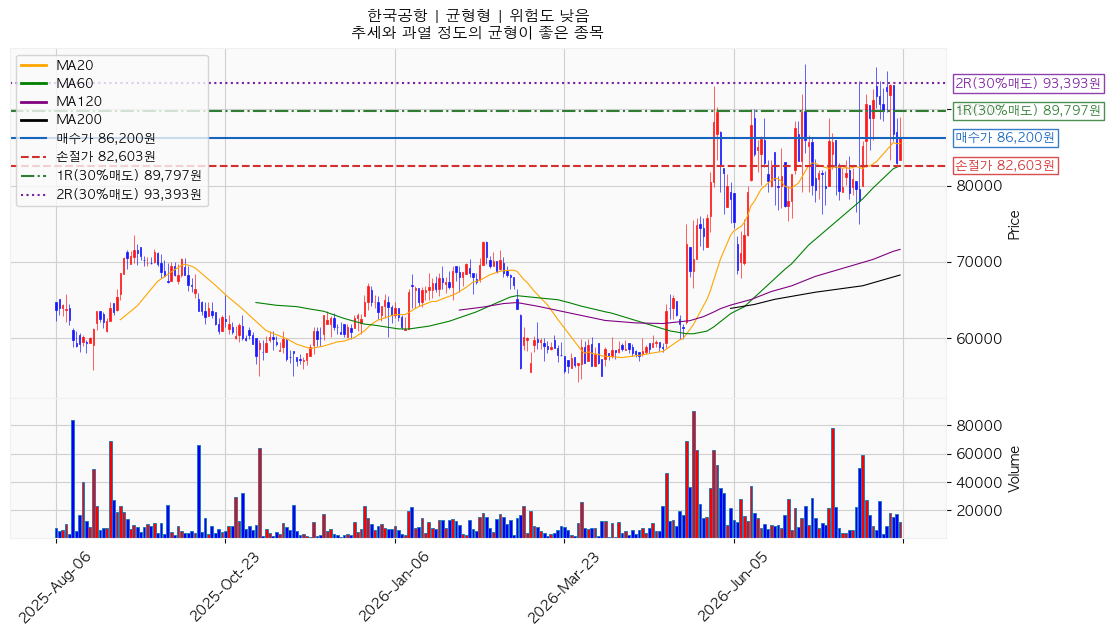

In [10]:
# matplotlib 폰트 관련 불필요한 경고 숨기기
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
import mplfinance as mpf

from IPython.display import display


# ==================================================
# 1. 기본 설정
# ==================================================

# 화면에 보여줄 전체 추천 종목 수
TOP_N = 20

# 차트를 그릴 종목 수
CHART_N = 10

# 최근 20일 평균 거래대금 최소 10억원
MIN_VALUE = 1_000_000_000

# 매수가 대비 최대 손실률 8%
STOP_RATE = 0.08


# 보고 싶은 종목 유형
opt = "균형형"

# opt = "강한추세"
# opt = "급등주의"
# opt = "과열주의"
# opt = "저과열"
# opt = "일반"
# opt = "전체"


# 실제 보유 종목의 매수가
# 예: {"021240": 98200}
BUY_PRICE = {}

# 실제 보유 종목의 손절가
# 예: {"021240": 92100}
BUY_STOP = {}


# 주가 데이터가 저장된 폴더
DATA_FOLDER = Path("stock_data")


# ==================================================
# 2. 한글 폰트 설정
# ==================================================

# 운영체제에 따라 한글 폰트 선택
font = {"Windows": "Malgun Gothic", "Darwin": "AppleGothic"}.get(
    platform.system(), "NanumGothic"
)


# 설치된 폰트 목록
available_fonts = {f.name for f in fm.fontManager.ttflist}


# 한글 폰트가 없으면 기본 영문 폰트 사용
if font not in available_fonts:
    font = "DejaVu Sans"


plt.rcParams["font.family"] = font

# 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


# ==================================================
# 3. KOSPI 시장 상태 확인
# ==================================================

# 저장해 둔 KOSPI 지수 데이터 읽기
kospi = pd.read_csv(
    DATA_FOLDER / "KS11.csv", index_col="Date", parse_dates=["Date"]
).sort_index()


# MA200 계산을 위해 최소 200일 필요
if len(kospi) < 200:
    raise RuntimeError("KOSPI 데이터가 200일보다 적습니다.")


# KOSPI 종가
kospi_close = kospi["Close"]

# 최근 KOSPI 지수
kospi_now = kospi_close.iloc[-1]

# 200일 이동평균
kospi_ma200 = kospi_close.rolling(200).mean().iloc[-1]

# KOSPI가 MA200보다 높으면 상승장
market_up = kospi_now > kospi_ma200

# 데이터 기준일
market_date = kospi.index[-1].date()


print("데이터 기준일 :", market_date)
print(f"KOSPI        : {kospi_now:,.2f}")
print(f"MA200        : {kospi_ma200:,.2f}")
print("시장 상태    :", "상승장" if market_up else "하락장")


# ==================================================
# 4. KOSPI 종목 목록 읽기
# ==================================================

stocks = pd.read_csv(DATA_FOLDER / "KOSPI_list.csv", dtype={"Code": str})


# 종목코드를 6자리 문자열로 맞추기
# 예: 5930 → 005930
stocks["Code"] = stocks["Code"].astype(str).str.zfill(6)


print("분석 대상 종목 :", len(stocks))


# ==================================================
# 5. 전체 종목 분석
# ==================================================

# 조건을 통과한 종목 저장
rows = []


# 모든 종목을 하나씩 분석
for _, stock in stocks.iterrows():
    code = stock["Code"]
    name = stock["Name"]

    stock_file = DATA_FOLDER / f"{code}.csv"

    # 주가 파일이 없으면 제외
    if not stock_file.exists():
        continue

    try:
        # 주가 데이터 읽기
        df = pd.read_csv(
            stock_file, index_col="Date", parse_dates=["Date"]
        ).sort_index()

        # MA120, 모멘텀 계산 등을 위해
        # 최소 130일 데이터 필요
        if len(df) < 130:
            continue

        # 종가
        close = df["Close"]

        # 현재 주가
        now = close.iloc[-1]

        # --------------------------------------------------
        # 이동평균선
        # --------------------------------------------------

        ma20 = close.rolling(20).mean()
        ma60 = close.rolling(60).mean()
        ma120 = close.rolling(120).mean()

        # --------------------------------------------------
        # 상승 정배열
        # 현재가 > MA20 > MA60 > MA120
        # --------------------------------------------------

        trend = now > ma20.iloc[-1] > ma60.iloc[-1] > ma120.iloc[-1]

        # --------------------------------------------------
        # 이동평균선 상승 여부
        # --------------------------------------------------

        # 현재 이동평균이 5거래일 전보다 높은지 확인
        rising = (
            ma20.iloc[-1] > ma20.iloc[-6]
            and ma60.iloc[-1] > ma60.iloc[-6]
            and ma120.iloc[-1] > ma120.iloc[-6]
        )

        # 상승 정배열이 아니거나
        # 이동평균선이 상승하지 않으면 제외
        if not (trend and rising):
            continue

        # ==================================================
        # 6. 투자 지표 계산
        # ==================================================

        # 하루 수익률
        daily_return = close.pct_change()

        # 최근 20일 수익률
        return20 = now / close.iloc[-21] - 1

        # 6개월 - 최근 1개월 모멘텀
        momentum = close.iloc[-22] / close.iloc[-126] - 1

        # 현재가와 MA20의 거리
        distance = now / ma20.iloc[-1] - 1

        # 최근 20일 평균 거래대금
        value = (close * df["Volume"]).tail(20).mean()

        # 최근 20일 변동성
        volatility = daily_return.tail(20).std()

        # 최근 5일 중 가장 높은 하루 상승률
        max_up = daily_return.tail(5).max()

        # ==================================================
        # 7. 기본 종목 필터
        # ==================================================

        # 거래대금 10억원 미만 제외
        if value < MIN_VALUE:
            continue

        # 모멘텀이 음수이면 제외
        if momentum <= 0:
            continue

        # 최근 20일 동안 30% 넘게 상승했으면 제외
        if return20 > 0.30:
            continue

        # MA20보다 15% 이상 높으면 제외
        if distance > 0.15:
            continue

        # 최근 5일 중 하루 20% 이상 급등했다면 제외
        if max_up > 0.20:
            continue

        # --------------------------------------------------
        # 조건을 통과한 종목 저장
        # --------------------------------------------------

        rows.append(
            {
                "Code": code,
                "Name": name,
                "Close": now,
                "MA20": ma20.iloc[-1],
                "MA60": ma60.iloc[-1],
                "MA120": ma120.iloc[-1],
                "Return20": return20,
                "Momentum": momentum,
                "Distance": distance,
                "Value": value,
                "Volatility": volatility,
            }
        )

    except Exception as e:
        print(f"{name} 오류 : {e}")


# ==================================================
# 8. 분석 결과 DataFrame 만들기
# ==================================================

result = pd.DataFrame(rows)


if result.empty:
    print("\n조건을 만족하는 종목이 없습니다.")


else:
    # ==================================================
    # 9. 매수 점수 계산
    # ==================================================

    # 모멘텀 : 40점
    result["모멘텀점수"] = result["Momentum"].rank(pct=True) * 40

    # MA20 이격도 : 30점
    # MA20보다 약 5% 높은 위치를 가장 높게 평가
    result["이격점수"] = (30 * (1 - abs(result["Distance"] - 0.05) / 0.10)).clip(0, 30)

    # 거래대금 : 15점
    result["유동성점수"] = result["Value"].rank(pct=True) * 15

    # 안정성 : 15점
    # 변동성이 낮을수록 높은 점수
    result["안정성점수"] = (1 - result["Volatility"].rank(pct=True)) * 15

    # 총점
    result["BuyScore"] = (
        result["모멘텀점수"]
        + result["이격점수"]
        + result["유동성점수"]
        + result["안정성점수"]
    )

    # 점수가 높은 종목부터 정렬
    result = result.sort_values("BuyScore", ascending=False).reset_index(drop=True)

    # ==================================================
    # 10. 종목 유형 분류
    # ==================================================

    # % 단위로 변환
    momentum_pct = result["Momentum"] * 100
    return20_pct = result["Return20"] * 100
    distance_pct = result["Distance"] * 100

    # 위에서부터 순서대로 조건 확인
    conditions = [
        # 장기 모멘텀이 매우 강함
        momentum_pct >= 80,
        # 최근 20일 급등
        return20_pct >= 20,
        # MA20에서 많이 떨어져 있음
        distance_pct >= 10,
        # 추세와 과열 정도가 균형적
        (
            (momentum_pct >= 15)
            & (momentum_pct <= 50)
            & (return20_pct <= 5)
            & (distance_pct <= 6)
        ),
        # MA20 근처
        distance_pct <= 3,
    ]

    types = ["강한추세", "급등주의", "과열주의", "균형형", "저과열"]

    result["유형"] = np.select(conditions, types, default="일반")

    # ==================================================
    # 11. 위험도와 설명
    # ==================================================

    risk_map = {
        "강한추세": "높음",
        "급등주의": "높음",
        "과열주의": "높음",
        "균형형": "낮음",
        "저과열": "낮음",
        "일반": "보통",
    }

    explain_map = {
        "강한추세": "추세는 매우 강하지만 이미 많이 오른 종목",
        "급등주의": "최근 급등하여 추격매수 주의",
        "과열주의": "상승 추세지만 MA20에서 다소 멀어진 상태",
        "균형형": "추세와 과열 정도의 균형이 좋은 종목",
        "저과열": "과열은 적지만 상승 힘을 더 확인할 종목",
        "일반": "무난한 상승 추세 종목",
    }

    result["위험도"] = result["유형"].map(risk_map)

    result["해석"] = result["유형"].map(explain_map)

    # ==================================================
    # 12. 화면 표시용 단위
    # ==================================================

    result["20일(%)"] = result["Return20"] * 100

    result["6-1M(%)"] = result["Momentum"] * 100

    result["MA20이격(%)"] = result["Distance"] * 100

    # 원 → 억원
    result["거래대금(억)"] = result["Value"] / 100_000_000

    # ==================================================
    # 13. 전체 추천 종목
    # ==================================================

    if market_up:
        print(f"\n[매수 후보 TOP {TOP_N}]")

    else:
        print(f"\n[관심 종목 TOP {TOP_N} - KOSPI MA200 하회]")

    display(
        result[
            [
                "Code",
                "Name",
                "Close",
                "BuyScore",
                "20일(%)",
                "6-1M(%)",
                "MA20이격(%)",
                "거래대금(억)",
                "유형",
                "위험도",
                "해석",
            ]
        ]
        .head(TOP_N)
        .round(2)
    )

    # ==================================================
    # 14. 원하는 유형 선택
    # ==================================================

    if opt == "전체":
        selected = result.head(CHART_N).copy()

    else:
        selected = result[result["유형"] == opt].head(CHART_N).copy()

    print(f"\n[{opt} - TOP {CHART_N}]")

    if selected.empty:
        print("해당 유형의 종목이 없습니다.")

    else:
        # ==================================================
        # 15. 매수가
        # ==================================================

        # 실제 매수가가 있으면 실제 가격 사용
        # 없으면 현재가를 임시 매수가로 사용
        selected["매수가"] = selected["Code"].map(BUY_PRICE).fillna(selected["Close"])

        # ==================================================
        # 16. 손절가
        # ==================================================

        # MA60과 매수가 -8% 중 높은 가격 사용
        auto_stop = pd.concat(
            [selected["MA60"], selected["매수가"] * (1 - STOP_RATE)], axis=1
        ).max(axis=1)

        # 직접 설정한 손절가가 있으면 우선 사용
        selected["손절가"] = selected["Code"].map(BUY_STOP).fillna(auto_stop)

        # ==================================================
        # 17. R / 분할 매도 가격
        # ==================================================

        # R = 매수가 - 손절가
        selected["R"] = selected["매수가"] - selected["손절가"]

        # 1R 도달 시 30% 매도
        selected["1R(30%매도)"] = selected["매수가"] + selected["R"]

        # 2R 도달 시 추가 30% 매도
        selected["2R(30%매도)"] = selected["매수가"] + selected["R"] * 2

        # ==================================================
        # 18. 현재 매도 단계
        # ==================================================

        price = selected["Close"]

        sell_conditions = [
            # 손절가 이하
            price <= selected["손절가"],
            # MA60 아래
            price < selected["MA60"],
            # MA20 아래
            price < selected["MA20"],
            # 2R 이상
            price >= selected["2R(30%매도)"],
            # 1R 이상
            price >= selected["1R(30%매도)"],
        ]

        selected["현재단계"] = np.select(
            sell_conditions,
            ["손절 구간", "추세 이탈", "MA20 이탈", "2R 이상", "1R 이상"],
            default="1R 전",
        )

        selected["매도신호"] = np.select(
            sell_conditions,
            ["전량 손절", "매도", "주의", "30% 매도 → 남은 40% MA20 추적", "30% 매도"],
            default="보유",
        )

        # ==================================================
        # 19. 매수 / 매도 계획 출력
        # ==================================================

        display(
            selected[
                [
                    "Code",
                    "Name",
                    "Close",
                    "MA20",
                    "MA60",
                    "매수가",
                    "손절가",
                    "1R(30%매도)",
                    "2R(30%매도)",
                    "현재단계",
                    "매도신호",
                ]
            ].round(0)
        )


# ==================================================
# 20. 캔들 차트 스타일
# ==================================================

# 한국식 캔들 색상
# 상승 = 빨강
# 하락 = 파랑
market_colors = mpf.make_marketcolors(up="red", down="blue", inherit=True)

# 이동평균선 색상
# MA20  = 주황
# MA60  = 초록
# MA120 = 보라
# MA200 = 검정
style = mpf.make_mpf_style(
    base_mpf_style="yahoo",
    marketcolors=market_colors,
    mavcolors=["orange", "green", "purple", "black"],
    rc={"font.family": font},
)


# 이동평균선 범례
ma_legend = [
    Line2D([0], [0], color="orange", lw=2, label="MA20"),
    Line2D([0], [0], color="green", lw=2, label="MA60"),
    Line2D([0], [0], color="purple", lw=2, label="MA120"),
    Line2D([0], [0], color="black", lw=2, label="MA200"),
]


# ==================================================
# 21. 종목별 캔들 차트
# ==================================================

for _, row in selected.iterrows():
    # 주가 데이터 읽기
    df = pd.read_csv(
        DATA_FOLDER / f"{row['Code']}.csv", index_col="Date", parse_dates=["Date"]
    ).sort_index()

    # --------------------------------------------------
    # 차트 제목
    # --------------------------------------------------

    title = f"{row['Name']} | {row['유형']} | 위험도 {row['위험도']}\n{row['해석']}"

    # --------------------------------------------------
    # 캔들 차트
    # --------------------------------------------------

    fig, axes = mpf.plot(
        # MA200 계산을 위해 200일보다 많은 데이터 사용
        df.tail(250),
        type="candle",
        # MA20 / MA60 / MA120 / MA200
        mav=(20, 60, 120, 200),
        volume=True,
        style=style,
        figsize=(13, 7),
        returnfig=True,
    )

    # 가격 차트
    ax = axes[0]

    # --------------------------------------------------
    # 제목
    # --------------------------------------------------

    ax.set_title(title, fontsize=11, pad=8)

    # --------------------------------------------------
    # 오른쪽 가격 표시 공간
    # --------------------------------------------------

    fig.subplots_adjust(right=0.80)

    # ==================================================
    # 22. 매수가 / 손절가 / 1R / 2R
    # ==================================================

    price_lines = [
        ("매수가", row["매수가"], "#1565C0", "-"),
        ("손절가", row["손절가"], "#D32F2F", "--"),
        ("1R(30%매도)", row["1R(30%매도)"], "#2E7D32", "-."),
        ("2R(30%매도)", row["2R(30%매도)"], "#7B1FA2", ":"),
    ]

    # 가격선 범례
    price_legend = []

    for label, price, color, line_style in price_lines:
        # 가격 수평선
        ax.axhline(y=price, color=color, linestyle=line_style, linewidth=1.5)

        # 오른쪽에 가격 표시
        ax.text(
            1.01,
            price,
            f"{label} {price:,.0f}원",
            transform=ax.get_yaxis_transform(),
            fontsize=9,
            color=color,
            va="center",
            ha="left",
            clip_on=False,
            bbox={"facecolor": "white", "edgecolor": color, "alpha": 0.85, "pad": 2},
        )

        # 가격선 범례
        price_legend.append(
            Line2D(
                [0],
                [0],
                color=color,
                linestyle=line_style,
                lw=1.5,
                label=f"{label} {price:,.0f}원",
            )
        )

    # ==================================================
    # 23. 전체 범례
    # ==================================================

    ax.legend(
        handles=ma_legend + price_legend, loc="upper left", frameon=True, fontsize=9
    )

    plt.show()
    plt.close(fig)


In [2]:
# end